Regularized Regression Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [4]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes (1).csv


In [5]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())


(768, 9)
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     

In [7]:
# Fill missing values with mean (numeric columns)
df = df.fillna(df.mean(numeric_only=True))

In [11]:
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [12]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [13]:
X = pd.get_dummies(X, drop_first=True)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(614, 8) (154, 8)


In [17]:
lin = LinearRegression()
lin.fit(X_train, y_train)

pred_lin = lin.predict(X_test)

rmse_lin = mean_squared_error(y_test, pred_lin)**0.5
r2_lin = r2_score(y_test, pred_lin)

print("Linear Regression RMSE:", rmse_lin)
print("Linear Regression R2:", r2_lin)

Linear Regression RMSE: 0.4135761995189049
Linear Regression R2: 0.25500281176741757


In [19]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_test)

rmse_ridge = mean_squared_error(y_test, pred_ridge)**0.5
r2_ridge = r2_score(y_test, pred_ridge)

print("Ridge RMSE:", rmse_ridge)
print("Ridge R2:", r2_ridge)

Ridge RMSE: 0.41364873868609703
Ridge R2: 0.25474145139436866


In [21]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

pred_lasso = lasso.predict(X_test)

rmse_lasso = mean_squared_error(y_test, pred_lasso)**0.5
r2_lasso = r2_score(y_test, pred_lasso)

print("Lasso RMSE:", rmse_lasso)
print("Lasso R2:", r2_lasso)

Lasso RMSE: 0.41897985164094875
Lasso R2: 0.2354078499579998


In [23]:
elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)
elastic.fit(X_train, y_train)

pred_elastic = elastic.predict(X_test)

rmse_elastic = mean_squared_error(y_test, pred_elastic)**0.5
r2_elastic = r2_score(y_test, pred_elastic)

print("ElasticNet RMSE:", rmse_elastic)
print("ElasticNet R2:", r2_elastic)

ElasticNet RMSE: 0.4162125907343353
ElasticNet R2: 0.24547438990190407


In [24]:
results = pd.DataFrame({
    'Model': ['Linear', 'Ridge', 'Lasso', 'ElasticNet'],
    'RMSE': [rmse_lin, rmse_ridge, rmse_lasso, rmse_elastic],
    'R2 Score': [r2_lin, r2_ridge, r2_lasso, r2_elastic]
})

results

,Model,RMSE,R2 Score
0,Linear,0.413576,0.255003
1,Ridge,0.413649,0.254741
2,Lasso,0.418980,0.235408
3,ElasticNet,0.416213,0.245474


In [25]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lin.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_,
    'ElasticNet': elastic.coef_
})

coef_df

,Feature,Linear,Ridge,Lasso,ElasticNet
0,Pregnancies,0.010468,0.010459,0.008970,0.009702
1,Glucose,0.005634,0.005635,0.005738,0.005689
2,BloodPressure,-0.002281,-0.002281,-0.002236,-0.002259
3,SkinThickness,0.000532,0.000537,0.000764,0.000657
4,Insulin,-0.000278,-0.000278,-0.000261,-0.000269
5,BMI,0.015039,0.015042,0.015077,0.015063
6,DiabetesPedigreeFunction,0.111263,0.109595,0.018146,0.061817
7,Age,0.006460,0.006462,0.006636,0.006552


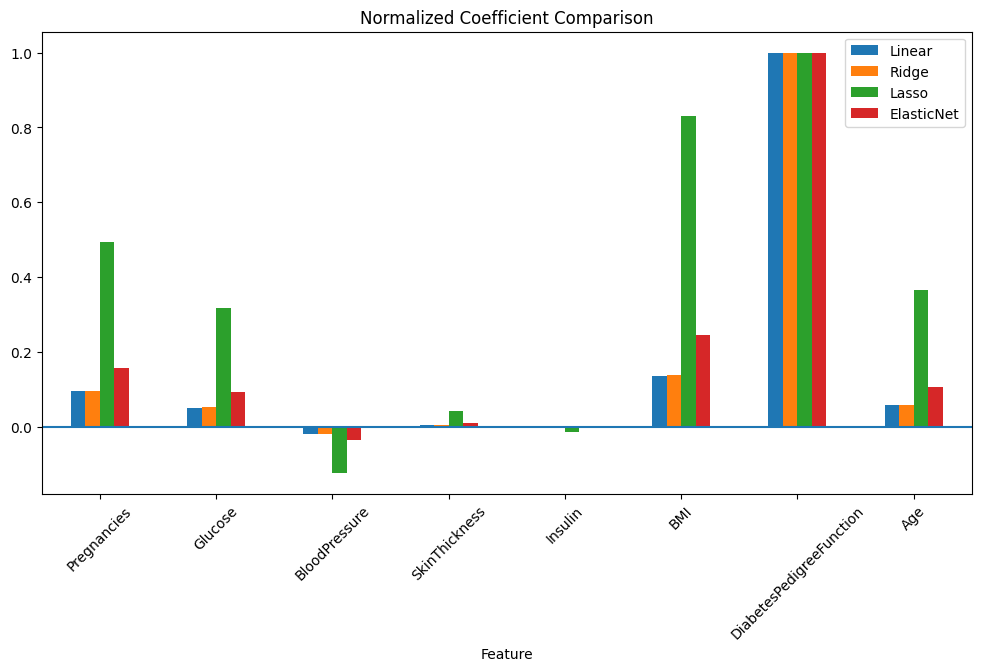

In [32]:
# 🔷 Normalize coefficients
coef_df_scaled = coef_df.copy()

for col in ['Linear', 'Ridge', 'Lasso', 'ElasticNet']:
    coef_df_scaled[col] = coef_df[col] / abs(coef_df[col]).max()

# 🔷 Plot normalized coefficients
coef_df_scaled.set_index('Feature').plot(kind='bar', figsize=(12,6))

plt.axhline(y=0)

plt.title("Normalized Coefficient Comparison")
plt.xticks(rotation=45)
plt.show()

In [27]:
best_model = results.loc[results['R2 Score'].idxmax()]
print("Best Model:\n", best_model)

Best Model:
 Model         Linear
RMSE        0.413576
R2 Score    0.255003
Name: 0, dtype: object


CONCLUSION:
Regularization improves model generalization and helps control overfitting while identifying important features